In [71]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [60]:
#df = pd.read_csv('mushrooms.csv')
df = pd.read_csv('employee_data.csv')

In [61]:
df.head()

,EmployeeID,EmployeeLevel,TenureYears,ProductGroup,Country,WorkLocation,TeamSize,PerformanceRating,SatisfactionScore
0,443683,1,2,GroupA,United States,hybrid,8,5.0,1
1,839543,1,1,GroupC,India,onsite,12,NaN,4
2,426374,1,2,GroupA,India,hybrid,7,2.0,5
3,327187,1,4,GroupB,Canada,hybrid,7,4.0,4
4,298314,1,3,GroupA,Canada,remote,5,5.0,3


In [62]:
# drop EmployeeID
df = df.drop('EmployeeID', axis=1)

# drop rows with missing values
df = df.dropna()

# convert SatisfactionScore to categorical
df['SatisfactionScore'] = df['SatisfactionScore'].astype('category')

In [89]:
df2 = pd.get_dummies(df)

df3 = df2.sample(frac=1)

In [90]:
df2.head()

,EmployeeLevel,TenureYears,TeamSize,PerformanceRating,ProductGroup_GroupA,ProductGroup_GroupB,ProductGroup_GroupC,ProductGroup_GroupD,Country_Canada,Country_India,Country_United States,WorkLocation_hybrid,WorkLocation_onsite,WorkLocation_remote,SatisfactionScore_1,SatisfactionScore_2,SatisfactionScore_3,SatisfactionScore_4,SatisfactionScore_5
0,1,2,8,5.0,True,False,False,False,False,False,True,True,False,False,True,False,False,False,False
2,1,2,7,2.0,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True
3,1,4,7,4.0,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False
4,1,3,5,5.0,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False
6,3,5,5,5.0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False


In [91]:
df3.head()

,EmployeeLevel,TenureYears,TeamSize,PerformanceRating,ProductGroup_GroupA,ProductGroup_GroupB,ProductGroup_GroupC,ProductGroup_GroupD,Country_Canada,Country_India,Country_United States,WorkLocation_hybrid,WorkLocation_onsite,WorkLocation_remote,SatisfactionScore_1,SatisfactionScore_2,SatisfactionScore_3,SatisfactionScore_4,SatisfactionScore_5
462,1,3,7,5.0,True,False,False,False,False,True,False,False,False,True,False,False,False,True,False
1145,3,17,4,4.0,False,False,False,True,False,False,True,True,False,False,False,False,False,True,False
1338,1,4,5,4.0,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False
2373,1,3,11,3.0,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True
624,2,3,3,3.0,True,False,False,False,False,True,False,False,True,False,False,False,True,False,False


In [92]:
X = df3.iloc[:,:-5]
y = df3.iloc[:,-5]

In [100]:
# get the count of each class
y.value_counts()

SatisfactionScore_1
False    3015
True      482
Name: count, dtype: int64

In [101]:
482 / (482 + 3015)

0.13783242779525307

In [94]:
X.head()

,EmployeeLevel,TenureYears,TeamSize,PerformanceRating,ProductGroup_GroupA,ProductGroup_GroupB,ProductGroup_GroupC,ProductGroup_GroupD,Country_Canada,Country_India,Country_United States,WorkLocation_hybrid,WorkLocation_onsite,WorkLocation_remote
462,1,3,7,5.0,True,False,False,False,False,True,False,False,False,True
1145,3,17,4,4.0,False,False,False,True,False,False,True,True,False,False
1338,1,4,5,4.0,True,False,False,False,False,True,False,True,False,False
2373,1,3,11,3.0,True,False,False,False,False,True,False,False,False,True
624,2,3,3,3.0,True,False,False,False,False,True,False,False,True,False


In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

print(rf.score(X_test, y_test))

0.8514285714285714


              precision    recall  f1-score   support

       False       0.89      0.95      0.92       773
        True       0.25      0.14      0.18       102

    accuracy                           0.85       875
   macro avg       0.57      0.54      0.55       875
weighted avg       0.82      0.85      0.83       875

 1) TeamSize                       0.317136
 2) TenureYears                    0.236683
 3) PerformanceRating              0.154121
 4) EmployeeLevel                  0.112244
 5) ProductGroup_GroupC            0.048307
 6) ProductGroup_GroupA            0.019918
 7) WorkLocation_onsite            0.019240
 8) Country_United States          0.018401
 9) WorkLocation_hybrid            0.015440
10) Country_India                  0.015127
11) ProductGroup_GroupB            0.014058
12) Country_Canada                 0.012092
13) WorkLocation_remote            0.011480
14) ProductGroup_GroupD            0.005753


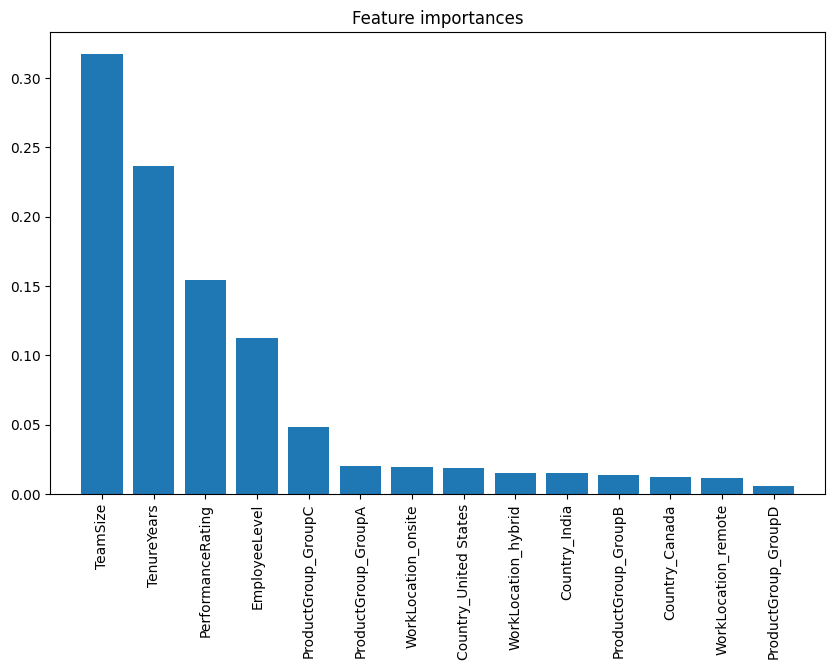

In [96]:
# print confusion matrix
from sklearn.metrics import confusion_matrix

y_pred = rf.predict(X_test)
confusion_matrix(y_test, y_pred)

# print classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# print feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

for f in range(X.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30, X.columns.values[indices[f]], importances[indices[f]]))

# plot feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns.values[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()



In [97]:
rf.feature_importances_

array([0.11224427, 0.23668327, 0.31713612, 0.1541211 , 0.01991763,
       0.01405777, 0.04830653, 0.00575273, 0.01209213, 0.01512687,
       0.01840087, 0.01544034, 0.01924005, 0.01148032])

In [98]:
# Obtaining feature names
rf.feature_names_in_

array(['EmployeeLevel', 'TenureYears', 'TeamSize', 'PerformanceRating',
       'ProductGroup_GroupA', 'ProductGroup_GroupB',
       'ProductGroup_GroupC', 'ProductGroup_GroupD', 'Country_Canada',
       'Country_India', 'Country_United States', 'WorkLocation_hybrid',
       'WorkLocation_onsite', 'WorkLocation_remote'], dtype=object)

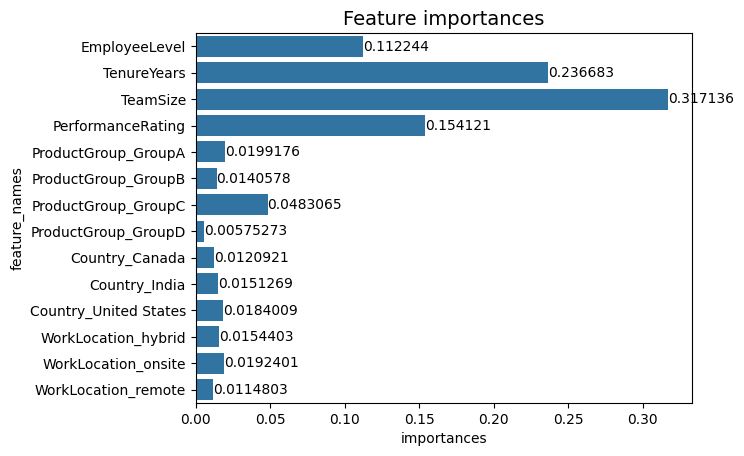

In [99]:
# Creating importances_df dataframe
importances_df = pd.DataFrame({"feature_names" : rf.feature_names_in_, 
                               "importances" : rf.feature_importances_})
                             
# Plotting bar chart, g is from graph
g = sns.barplot(data=importances_df, 
                x="importances", 
                y="feature_names")
g.set_title("Feature importances", fontsize=14)
for value in g.containers:
    g.bar_label(value)

In [102]:
df3.corr().round(2)

,EmployeeLevel,TenureYears,TeamSize,PerformanceRating,ProductGroup_GroupA,ProductGroup_GroupB,ProductGroup_GroupC,ProductGroup_GroupD,Country_Canada,Country_India,Country_United States,WorkLocation_hybrid,WorkLocation_onsite,WorkLocation_remote,SatisfactionScore_1,SatisfactionScore_2,SatisfactionScore_3,SatisfactionScore_4,SatisfactionScore_5
EmployeeLevel,1.00,0.46,-0.01,-0.01,-0.03,0.01,-0.00,0.06,0.00,-0.03,0.02,-0.01,0.00,0.01,0.05,0.04,0.03,-0.05,-0.06
TenureYears,0.46,1.00,0.02,-0.02,-0.01,0.01,-0.01,0.01,0.02,-0.00,-0.02,-0.01,0.01,-0.00,0.11,0.09,0.06,-0.06,-0.17
TeamSize,-0.01,0.02,1.00,-0.13,-0.24,-0.14,0.54,-0.17,-0.15,0.12,0.02,-0.15,0.30,-0.16,0.17,0.08,-0.01,-0.09,-0.11
PerformanceRating,-0.01,-0.02,-0.13,1.00,0.16,0.01,-0.27,0.10,0.06,-0.04,-0.01,0.07,-0.16,0.09,-0.08,-0.05,-0.01,0.06,0.07
ProductGroup_GroupA,-0.03,-0.01,-0.24,0.16,1.00,-0.58,-0.50,-0.22,0.17,0.16,-0.28,0.15,-0.27,0.12,-0.16,-0.11,0.03,0.09,0.10
ProductGroup_GroupB,0.01,0.01,-0.14,0.01,-0.58,1.00,-0.29,-0.13,0.10,-0.31,0.18,0.06,-0.12,0.07,-0.08,-0.03,0.01,0.04,0.04
ProductGroup_GroupC,-0.00,-0.01,0.54,-0.27,-0.50,-0.29,1.00,-0.11,-0.27,0.20,0.05,-0.27,0.55,-0.29,0.29,0.17,-0.04,-0.17,-0.18
ProductGroup_GroupD,0.06,0.01,-0.17,0.10,-0.22,-0.13,-0.11,1.00,-0.12,-0.12,0.20,0.05,-0.15,0.11,-0.02,-0.01,-0.03,0.02,0.03
Country_Canada,0.00,0.02,-0.15,0.06,0.17,0.10,-0.27,-0.12,1.00,-0.29,-0.59,0.11,-0.13,0.03,-0.08,-0.07,0.02,0.05,0.06
Country_India,-0.03,-0.00,0.12,-0.04,0.16,-0.31,0.20,-0.12,-0.29,1.00,-0.60,-0.06,0.11,-0.05,0.05,0.01,0.02,-0.04,-0.03
